# Chapter 1 Companion Notebook: Uncertainty, Expected Value, and Risk Aversion

This notebook reproduces the numerical examples from Chapter 1 of *AI in Finance* (`chapter1.tex`, Sections 1.6.1, 1.6.2, 1.15, and 1.16) and extends them with a plot of the risk-return tradeoff, a simple risk-aversion (utility) illustration, a time-value-of-money check, a two-step sequential Bayesian updating example, a Kelly-criterion bet-sizing example, and an expected-value-of-perfect-information (EVPI) calculation.

---

**© 2026 Wulin Suo. All rights reserved.** This notebook is a companion to the draft manuscript *AI in Finance* and is provided for personal, educational use. No part of this notebook may be reproduced, distributed, or transmitted in any form or by any means without the prior written permission of the author, except for brief quotations in a review. Contact: Wulin.Suo@Queensu.ca

## 1. Expected value of a simple gamble

A gamble offers a 50% chance of gaining \$20,000 and a 50% chance of losing \$10,000. Compute its expected value, matching the chapter's worked example.

In [1]:
p_gain, x_gain = 0.5, 20_000
p_loss, x_loss = 0.5, -10_000

expected_value = p_gain * x_gain + p_loss * x_loss
print(f"Expected value: ${expected_value:,.2f}")

Expected value: $5,000.00


## 2. Risk aversion and the certainty equivalent

A risk-neutral investor should accept any gamble with positive expected value. A risk-averse investor evaluates gambles using **expected utility** instead. Here we use a simple constant relative risk aversion (CRRA) utility function

$$u(w) = \frac{w^{1-\gamma}}{1-\gamma}, \qquad \gamma > 0,\ \gamma \neq 1$$

applied to total wealth (starting wealth plus the gamble's payoff), and find the certainty equivalent: the guaranteed amount that gives the same expected utility as the gamble.

In [2]:
import numpy as np
from scipy.optimize import brentq

def crra_utility(wealth, gamma):
    return wealth ** (1 - gamma) / (1 - gamma)

def crra_inverse(utility, gamma):
    return (utility * (1 - gamma)) ** (1 / (1 - gamma))

starting_wealth = 100_000
gamma = 2.0  # risk-aversion coefficient

outcomes = np.array([starting_wealth + x_gain, starting_wealth + x_loss])
probs = np.array([p_gain, p_loss])

expected_utility = np.sum(probs * crra_utility(outcomes, gamma))
certainty_equivalent_wealth = crra_inverse(expected_utility, gamma)
certainty_equivalent_payoff = certainty_equivalent_wealth - starting_wealth
risk_premium = expected_value - certainty_equivalent_payoff

print(f"Expected utility: {expected_utility:.6f}")
print(f"Certainty-equivalent payoff: ${certainty_equivalent_payoff:,.2f}")
print(f"Risk premium (EV - CE): ${risk_premium:,.2f}")

Expected utility: -0.000010
Certainty-equivalent payoff: $2,857.14
Risk premium (EV - CE): $2,142.86


With $\gamma = 2$, the certainty equivalent payoff is well below the \$5,000 expected value, and the gap between the two (the risk premium) is the amount this investor would sacrifice to avoid the gamble's uncertainty entirely. Try changing `gamma` above (e.g. to 0.5 or 5) and re-running the cell to see how the risk premium grows with risk aversion.

### 2b. A concrete square-root-utility example (Section 1.15)

The chapter text works through a specific, simpler case: square-root utility $u(W) = \sqrt{W}$ applied to a starting wealth of $W_0 = \$50{,}000$, rather than the general CRRA function above. Reproduce that calculation exactly.

In [3]:
W0 = 50_000
W_up = W0 + x_gain   # $70,000
W_down = W0 + x_loss  # $40,000

u = lambda W: W ** 0.5

Eu_sqrt = p_gain * u(W_up) + p_loss * u(W_down)
CE_wealth = Eu_sqrt ** 2
E_wealth = p_gain * W_up + p_loss * W_down
risk_premium_sqrt = E_wealth - CE_wealth

print(f"u(W_up)={u(W_up):.3f}  u(W_down)={u(W_down):.3f}")
print(f"E[u(W)] = {Eu_sqrt:.3f}")
print(f"Certainty-equivalent wealth: ${CE_wealth:,.2f}")
print(f"Expected wealth: ${E_wealth:,.2f}")
print(f"Risk premium: ${risk_premium_sqrt:,.2f}")

u(W_up)=264.575  u(W_down)=200.000
E[u(W)] = 232.288
Certainty-equivalent wealth: $53,957.51
Expected wealth: $55,000.00
Risk premium: $1,042.49


## 3. Visualizing the risk-return tradeoff

Section 1.4.1 describes the risk-return tradeoff qualitatively. Here is a simple stylized plot: expected return as an increasing, concave function of risk, with three illustrative portfolios (low, medium, high risk).

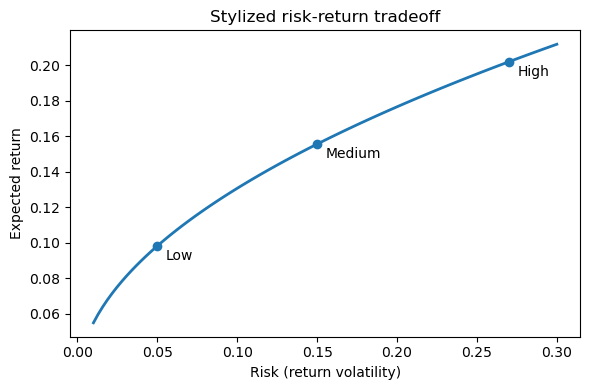

In [4]:
import matplotlib.pyplot as plt

risk = np.linspace(0.01, 0.30, 100)
expected_return = 0.02 + 0.35 * np.sqrt(risk)  # stylized concave tradeoff

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(risk, expected_return, color='tab:blue', linewidth=2)

portfolios = {'Low': 0.05, 'Medium': 0.15, 'High': 0.27}
for label, r in portfolios.items():
    er = 0.02 + 0.35 * np.sqrt(r)
    ax.scatter(r, er, color='tab:blue', zorder=3)
    ax.annotate(label, (r, er), textcoords='offset points', xytext=(6, -10))

ax.set_xlabel('Risk (return volatility)')
ax.set_ylabel('Expected return')
ax.set_title('Stylized risk-return tradeoff')
plt.tight_layout()
plt.show()

## 4. Time value of money (Table 1.3)

Section 1.6.2 tabulates the future value of \$1,000 invested at three rates over three horizons, $FV = PV(1+r)^n$. Reproduce the table here.

In [5]:
import pandas as pd

PV = 1_000
rates = [0.03, 0.06, 0.09]
horizons = [10, 20, 30]

fv_table = pd.DataFrame(
    {n: [PV * (1 + r) ** n for r in rates] for n in horizons},
    index=[f"{int(r*100)}%" for r in rates],
)
fv_table.columns = [f"{n} years" for n in horizons]
fv_table.round(2)

,10 years,20 years,30 years
3%,1343.92,1806.11,2427.26
6%,1790.85,3207.14,5743.49
9%,2367.36,5604.41,13267.68


## 5. Bayesian updating: fraud detection example (Section 1.16)

Only 1% of transactions are fraudulent. A fraud model flags 95% of true fraud but also flags 3% of legitimate transactions. Given a transaction is flagged, what is the probability it is actually fraudulent? Apply Bayes' theorem.

In [6]:
p_fraud = 0.01
p_flag_given_fraud = 0.95
p_flag_given_not_fraud = 0.03

p_not_fraud = 1 - p_fraud
p_flag = p_flag_given_fraud * p_fraud + p_flag_given_not_fraud * p_not_fraud
p_fraud_given_flag = (p_flag_given_fraud * p_fraud) / p_flag

print(f"P(Flag) = {p_flag:.4f}")
print(f"P(Fraud | Flag) = {p_fraud_given_flag:.4f}")

P(Flag) = 0.0392
P(Fraud | Flag) = 0.2423


### 5b. Sequential Bayesian updating: a second piece of evidence (Section 1.16)

The flagged transaction's posterior, `p_fraud_given_flag` above, now becomes the *prior* for a second, independent signal: whether the transaction occurred somewhere the customer has never transacted before (true for 60% of fraud, 10% of legitimate transactions).

In [7]:
p_loc_given_fraud = 0.6
p_loc_given_not_fraud = 0.1

prior2 = p_fraud_given_flag  # posterior from the first update
p_loc = p_loc_given_fraud * prior2 + p_loc_given_not_fraud * (1 - prior2)
p_fraud_given_both = (p_loc_given_fraud * prior2) / p_loc

print(f"Prior for second update (posterior from first): {prior2:.4f}")
print(f"P(Unusual Location) = {p_loc:.4f}")
print(f"P(Fraud | Flag, Unusual Location) = {p_fraud_given_both:.4f}")

Prior for second update (posterior from first): 0.2423
P(Unusual Location) = 0.2212
P(Fraud | Flag, Unusual Location) = 0.6574


## 6. The Kelly criterion: optimal bet sizing (Section 1.13)

For a repeatable even-money bet with a 60% win probability, find the optimal fraction of wealth to wager, and show that over-betting (even with a real edge) produces negative long-run growth.

In [8]:
p_win, b_odds = 0.6, 1.0
q_lose = 1 - p_win

f_star = p_win - q_lose / b_odds
print(f"Kelly-optimal fraction: {f_star:.4f}")

def growth_rate(f, p=p_win, q=q_lose):
    return p * np.log(1 + f) + q * np.log(1 - f)

for f in [0.2, 0.5]:
    print(f"Growth rate at f={f}: {growth_rate(f):.4f}")
print("Growth rate at f=1.0: -inf (guaranteed eventual ruin, since q > 0)")

# Exercise: p=0.7 win probability
p_ex, q_ex = 0.7, 0.3
f_star_ex = p_ex - q_ex
print(f"\nExercise (p=0.7) -- f*={f_star_ex:.4f}")
print(f"Growth at f*: {growth_rate(f_star_ex, p_ex, q_ex):.4f}")
print(f"Growth at f=0.9: {growth_rate(0.9, p_ex, q_ex):.4f}")

Kelly-optimal fraction: 0.2000
Growth rate at f=0.2: 0.0201
Growth rate at f=0.5: -0.0340
Growth rate at f=1.0: -inf (guaranteed eventual ruin, since q > 0)

Exercise (p=0.7) -- f*=0.4000
Growth at f*: 0.0823
Growth at f=0.9: -0.2415


## 7. The expected value of perfect information (Section 1.13)

A $2 million project succeeds (prob. 0.4, gain $5M) or fails (prob. 0.6, lose $2M). Compute EVPI: the most a firm should pay for a perfectly accurate forecast before deciding.

In [9]:
p_success, p_fail = 0.4, 0.6
gain_success, loss_fail = 5.0, -2.0

ev_proceed = p_success * gain_success + p_fail * loss_fail
best_without_info = max(ev_proceed, 0.0)
ev_perfect_info = p_success * gain_success + p_fail * max(loss_fail, 0.0)
evpi = ev_perfect_info - best_without_info

print(f"EV(proceed) = ${ev_proceed:.2f}M")
print(f"EV(perfect information) = ${ev_perfect_info:.2f}M")
print(f"EVPI = ${evpi:.2f}M")

# Exercise: market-entry decision
p_s_ex, p_f_ex = 0.3, 0.7
gain_ex, loss_ex = 12.0, -3.0
ev_enter_ex = p_s_ex * gain_ex + p_f_ex * loss_ex
best_ex = max(ev_enter_ex, 0.0)
ev_perfect_ex = p_s_ex * gain_ex + p_f_ex * max(loss_ex, 0.0)
evpi_ex = ev_perfect_ex - best_ex
print(f"\nExercise -- EV(enter)=${ev_enter_ex:.2f}M, EV(perfect info)=${ev_perfect_ex:.2f}M, EVPI=${evpi_ex:.2f}M")
print(f"Worth paying $4M for the report? {evpi_ex > 4.0}")

EV(proceed) = $0.80M
EV(perfect information) = $2.00M
EVPI = $1.20M

Exercise -- EV(enter)=$1.50M, EV(perfect info)=$3.60M, EVPI=$2.10M
Worth paying $4M for the report? False


## Exercise (matches Chapter 1, Suggested Exercise 8)

A gamble offers a 60% chance of gaining \$8,000 and a 40% chance of losing \$5,000. Compute its expected value below, then compute the certainty equivalent using the CRRA utility function above with $\gamma = 2$.

In [10]:
# Your turn: compute the expected value of the new gamble
p_gain2, x_gain2 = 0.6, 8_000
p_loss2, x_loss2 = 0.4, -5_000
ev2 = p_gain2 * x_gain2 + p_loss2 * x_loss2
print(f"Expected value: ${ev2:,.2f}")

outcomes2 = np.array([starting_wealth + x_gain2, starting_wealth + x_loss2])
probs2 = np.array([p_gain2, p_loss2])
eu2 = np.sum(probs2 * crra_utility(outcomes2, gamma))
ce2 = crra_inverse(eu2, gamma) - starting_wealth
print(f"Certainty-equivalent payoff: ${ce2:,.2f}")
print(f"Risk premium: ${ev2 - ce2:,.2f}")

Expected value: $2,800.00
Certainty-equivalent payoff: $2,395.21
Risk premium: $404.79
